In [67]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [68]:
file = uproot.open("/lstr/sahara/dune/arahe/CP2Course/CP2GroupProject/TylerStuff/CCode/Analysis/gen1_mu_cc_1000_events_new.root")

In [69]:
tree = file["ana;1"]

In [70]:
branch = tree["gen1;1"]

In [71]:
Reco = branch.arrays(['eventID',
                      'recoNParticles',
                      'reco',
                      'recoGeneration',
                      'recoTrackLength',
                      'recoTrackScore',
                      'recodEdx',
                      'recoResidualRange'])
Sim = branch.arrays(['simNParticles',
                     'sim',
                     'simGeneration',
                     'simPdgCode',
                     'simEnergy',
                     'simID'])

In [72]:
rec = ak.zip({
    "eventID" : Reco['eventID'],
    "recoNParticles" : Reco['recoNParticles'],
    "recoGeneration" : Reco['recoGeneration'],
    "recoTrackLength" : Reco['recoTrackLength'],
    "recoTrackScore" : Reco['recoTrackScore'],
    "recodEdx" : Reco['recodEdx'],
    "recoResidualRange" : Reco['recoResidualRange']
})

In [73]:
sim = ak.zip({
    "simNParticles" : Sim['simNParticles'],
    "sim" : Sim["sim"],
    "simGeneration" : Sim['simGeneration'],
    "simPdgCode" : Sim["simPdgCode"],
    "simEnergy" : Sim['simEnergy'],
    "simID" : Sim["simID"]
})

In [74]:
#rec.recodEdx

In [145]:
def energyperlength(energy, length):
    #Calculates dEdx per Tracklength
    result = energy / length
    return result

In [76]:
#energyperlength(rec.recodEdx,rec.recoTrackLength)

In [269]:
def recocuts(reco):
    #Apply cuts
    e_and_l_cut = (reco.recodEdx<5000) & (reco.recoTrackLength>100)
    cleaned_e_and_l = reco[e_and_l_cut]
    #Get dEdx per TrackLength
    e_per_l = energyperlength(cleaned_e_and_l.recodEdx, cleaned_e_and_l.recoTrackLength)
    return e_per_l

In [270]:
thething = recocuts(rec)
thething

<Array [[[], [0.0119, ..., 0.0141]], ...] type='935 * var * var * float32'>

In [291]:
flatten_data_for_histogram = ak.ravel(ak.Array(thething))
flatten_data_for_histogram

<Array [0.0119, 0.00658, ..., 0.00402, 0.00419] type='887139 * float32'>

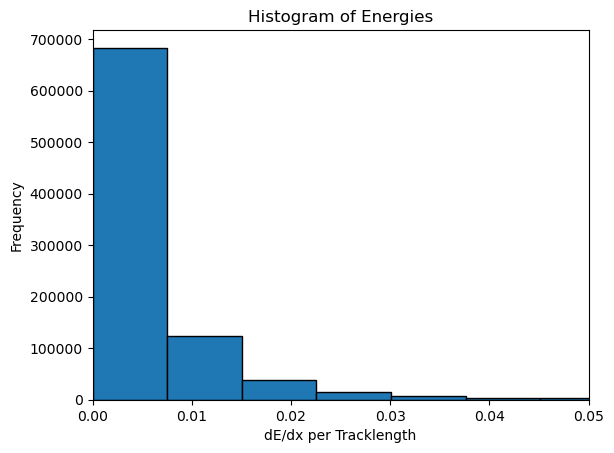

In [292]:
plt.hist(flatten_data_for_histogram, bins=5000, edgecolor = 'black')
plt.xlim(0, 0.05)
#plt.ylim(0,5)
plt.xlabel('dE/dx per Tracklength')
plt.ylabel('Frequency')
plt.title('Histogram of Energies')
plt.show()

In [279]:
def simcuts(sim):
    #Apply cuts
    e_cut = (sim.simPdgCode == 11)
    cleaned_e = sim[e_cut]
    return cleaned_e.simEnergy

In [280]:
yessir = simcuts(sim)
yessir

<Array [[], [0.0221, 0.036, ..., 0.341], ..., []] type='935 * var * float32'>

In [293]:
flatten_simdata_for_histogram = ak.ravel(ak.Array(yessir))
flatten_simdata_for_histogram

<Array [0.0221, 0.036, 0.0436, ..., 0.111, 0.0304, 0.06] type='917 * float32'>

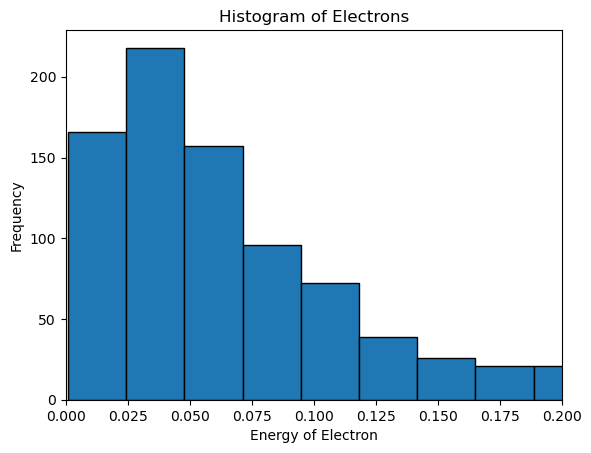

In [298]:
plt.hist(flatten_simdata_for_histogram, bins=500, edgecolor = 'black')
plt.xlim(0, 0.2)
#plt.ylim(0,5)
plt.xlabel('Energy of Electron')
plt.ylabel('Frequency')
plt.title('Histogram of Electrons')
plt.show()